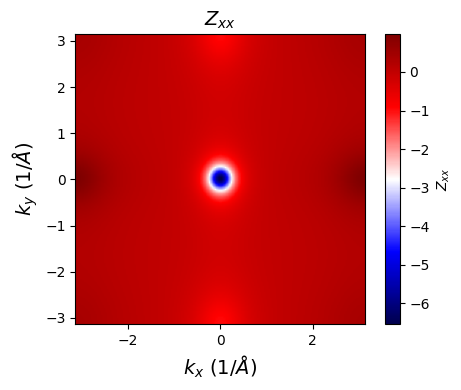

/tmp/ipython-input-162398200.py:115: RuntimeWarning: overflow encountered in exp
  f1 = 1.0 / (np.exp((E1_grid - mu) / (K_B * T)) + 1.0)
/tmp/ipython-input-162398200.py:116: RuntimeWarning: overflow encountered in exp
  f2 = 1.0 / (np.exp((E2_grid - mu) / (K_B * T)) + 1.0)


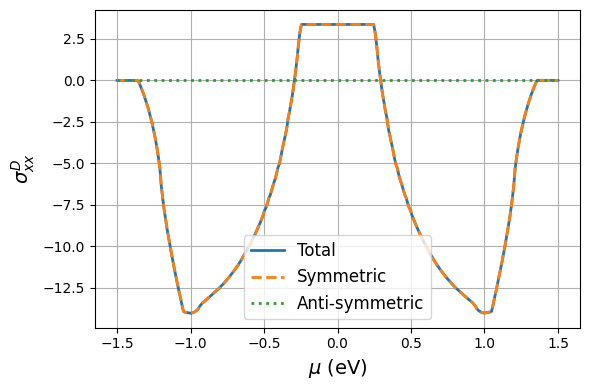

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Pauli matrices ----------------
sigma_0 = np.array([[1, 0], [0, 1]], dtype=complex)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

# ---------------- Parameters ----------------
NP = 200           # use 400 for higher resolution
v_f = 0.825
beta = 0.25
m = 0.1
lam = np.pi
kx = np.linspace(-lam, lam, NP)
ky = np.linspace(-lam, lam, NP)

# ---------------- Hamiltonian grid ----------------
H = np.zeros((2, 2, NP, NP), dtype=complex)
for ix, kxi in enumerate(kx):
    for iy, kyj in enumerate(ky):
        p1 = v_f * (np.sin(kyj) * sigma_x - np.sin(kxi) * sigma_y)
        p2 = beta * sigma_z
        p3 = (2 * m) * (2 - np.cos(kxi) - np.cos(kyj)) * sigma_z
        H[:, :, ix, iy] = p1 + p2 + p3

# ---------------- Derivatives dH/dkx, dH/dky ----------------
H_kx = np.zeros_like(H)
H_ky = np.zeros_like(H)

for ix in range(NP):
    for iy in range(NP):
        if 0 < ix < NP - 1:
            dkx = kx[ix + 1] - kx[ix - 1]
            H_kx[:, :, ix, iy] = (H[:, :, ix + 1, iy] - H[:, :, ix - 1, iy]) / dkx
        elif ix == 0:
            dkx = kx[1] - kx[0]
            H_kx[:, :, ix, iy] = (H[:, :, ix + 1, iy] - H[:, :, ix, iy]) / dkx
        else:
            dkx = kx[-1] - kx[-2]
            H_kx[:, :, ix, iy] = (H[:, :, ix, iy] - H[:, :, ix - 1, iy]) / dkx

for ix in range(NP):
    for iy in range(NP):
        if 0 < iy < NP - 1:
            dky = ky[iy + 1] - ky[iy - 1]
            H_ky[:, :, ix, iy] = (H[:, :, ix, iy + 1] - H[:, :, ix, iy - 1]) / dky
        elif iy == 0:
            dky = ky[1] - ky[0]
            H_ky[:, :, ix, iy] = (H[:, :, ix, iy + 1] - H[:, :, ix, iy]) / dky
        else:
            dky = ky[-1] - ky[-2]
            H_ky[:, :, ix, iy] = (H[:, :, ix, iy] - H[:, :, ix, iy - 1]) / dky

# ---------------- Compute Zxx components ----------------
zxx1_1 = np.zeros((NP, NP))
zxx2_2 = np.zeros((NP, NP))
zxx3_3 = np.zeros((NP, NP))
zxx4_4 = np.zeros((NP, NP))

epsilon = 1e-4

for ix in range(NP):
    for iy in range(NP):
        H_curr = H[:, :, ix, iy]
        Hkx_curr = H_kx[:, :, ix, iy]
        Hky_curr = H_ky[:, :, ix, iy]
        E, V = np.linalg.eigh(H_curr)
        v1, v2 = V[:, 0], V[:, 1]
        E1, E2 = E[0], E[1]

        sigma12x = np.vdot(v1, sigma_x @ v2)
        sigma21x = np.vdot(v2, sigma_x @ v1)
        v12x = np.vdot(v1, Hkx_curr @ v2)
        v21x = np.vdot(v2, Hkx_curr @ v1)

        den1 = 1j * (E1 - E2 + epsilon) ** 2
        den2 = 1j * (E2 - E1 + epsilon) ** 2
        zxx1_1[ix, iy] = np.real(2 * v12x * sigma21x / den1)
        zxx2_2[ix, iy] = np.real(2 * v21x * sigma12x / den2)
        zxx3_3[ix, iy] = np.real(2 * v12x * sigma21x / den1)
        zxx4_4[ix, iy] = np.real(2 * v21x * sigma12x / den2)

# ---------------- Plot one Zxx map ----------------
plt.figure(figsize=(5, 4))
plt.imshow(zxx1_1.T, extent=[kx.min(), kx.max(), ky.min(), ky.max()],
           origin='lower', cmap='seismic')
plt.xlabel(r'$k_x$ ($1/\AA$)', fontsize=14)
plt.ylabel(r'$k_y$ ($1/\AA$)', fontsize=14)
plt.title(r'$Z_{xx}$', fontsize=14)
plt.colorbar(label=r'$Z_{xx}$')
plt.tight_layout()
plt.show()

# ---------------- Conductivity vs mu ----------------
E1_grid = np.zeros((NP, NP))
E2_grid = np.zeros((NP, NP))
for ix in range(NP):
    for iy in range(NP):
        E, _ = np.linalg.eigh(H[:, :, ix, iy])
        E1_grid[ix, iy], E2_grid[ix, iy] = E[0], E[1]

N = 300
mu_vals = np.linspace(-1.5, 1.5, N)
K_B = 8.6e-5
T = 1.0
dk = (2 * np.pi / (NP - 1)) ** 2

sigma = np.zeros(N)
sigma_sT = np.zeros(N)
sigma_asT = np.zeros(N)

for k, mu in enumerate(mu_vals):
    f1 = 1.0 / (np.exp((E1_grid - mu) / (K_B * T)) + 1.0)
    f2 = 1.0 / (np.exp((E2_grid - mu) / (K_B * T)) + 1.0)
    sigma1 = np.sum(zxx1_1 * f1) * dk
    sigma2 = np.sum(zxx2_2 * f2) * dk
    sigma1_s = np.sum((zxx1_1 + zxx3_3) * f1) * dk
    sigma2_s = np.sum((zxx2_2 + zxx4_4) * f2) * dk
    sigma1_as = np.sum((zxx1_1 - zxx3_3) * f1) * dk
    sigma2_as = np.sum((zxx2_2 - zxx4_4) * f2) * dk

    sigma[k] = -2 * np.pi * (sigma1 + sigma2)
    sigma_sT[k] = -np.pi * (sigma1_s + sigma2_s)
    sigma_asT[k] = -np.pi * (sigma1_as + sigma2_as)

# ---------------- Plot σxx^D vs μ ----------------
plt.figure(figsize=(6, 4))
plt.plot(mu_vals, sigma, label='Total', lw=2)
plt.plot(mu_vals, sigma_sT, '--', label='Symmetric', lw=2)
plt.plot(mu_vals, sigma_asT, ':', label='Anti-symmetric', lw=2)
plt.xlabel(r'$\mu$ (eV)', fontsize=14)
plt.ylabel(r'$\sigma_{xx}^{D}$', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()
